<a href="https://colab.research.google.com/github/onja1119-hash/MDS650-mortgage-early-warning/blob/main/MDS650_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas numpy scipy scikit-learn imbalanced-learn xgboost shap matplotlib joblib

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os

DATA_DIR = "/content/drive/MyDrive/MDS650/FreddieMac"
FIGURE_DIR = "/content/drive/MyDrive/MDS650/Figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

print("Data folder exists:", os.path.exists(DATA_DIR))
print("Figure folder:", FIGURE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data folder exists: True
Figure folder: /content/drive/MyDrive/MDS650/Figures


In [ ]:
# Import all libraries

import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss,
    log_loss
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
YEARS = [2015, 2016, 2017, 2018]
LGD = 0.50
FP_COST = 500

In [ ]:
# Define Freddie Mac origination and servicing column names

orig_cols = [
    "credit_score","first_payment_date","first_time_homebuyer_flag","maturity_date",
    "msa","mi_percent","number_of_units","occupancy_status","original_cltv",
    "original_dti","original_upb","original_ltv","original_interest_rate","channel",
    "prepayment_penalty_flag","product_type","property_state","property_type",
    "postal_code","loan_sequence_number","loan_purpose","original_loan_term",
    "number_of_borrowers","seller_name","servicer_name","super_conforming_flag",
    "pre_harp_loan_sequence_number","program_indicator","harp_indicator",
    "property_valuation_method","interest_only_indicator","mi_cancellation_indicator"
]

svcg_cols = [
    "loan_sequence_number","monthly_reporting_period","current_actual_upb",
    "current_loan_delinquency_status","loan_age","remaining_months_to_legal_maturity",
    "defect_settlement_date","modification_flag","zero_balance_code",
    "zero_balance_effective_date","current_interest_rate","current_deferred_upb",
    "due_date_last_paid_installment","mi_recoveries","net_sales_proceeds",
    "non_mi_recoveries","expenses","legal_costs","maintenance_preservation_costs",
    "taxes_insurance","misc_expenses","actual_loss_calculation","modification_cost",
    "step_modification_flag","deferred_payment_plan","estimated_ltv",
    "zero_balance_removal_upb","delinquent_accrued_interest",
    "delinquency_due_to_disaster","borrower_assistance_status_code",
    "current_month_modification_cost","interest_bearing_upb"
]

In [ ]:
# Load and combine the 2015–2018 origination files

orig_frames = []

for year in YEARS:
    df = pd.read_csv(
        os.path.join(DATA_DIR, f"sample_orig_{year}.txt"),
        sep="|",
        names=orig_cols,
        low_memory=False
    )

    df["vintage"] = year
    orig_frames.append(df)

orig = pd.concat(orig_frames, ignore_index=True)

print("Origination rows:", f"{len(orig):,}")
print("Unique loans:", f"{orig['loan_sequence_number'].nunique():,}")
print(orig["vintage"].value_counts().sort_index())

Origination rows: 200,000
Unique loans: 200,000
vintage
2015    50000
2016    50000
2017    50000
2018    50000
Name: count, dtype: int64


In [ ]:
# Inspect missing values in all origination variables

missing_summary = (
    orig.isna()
    .sum()
    .to_frame("NaN_Count")
)

missing_summary["Missing_Percent"] = (
    missing_summary["NaN_Count"] / len(orig) * 100
)

display(
    missing_summary[
        missing_summary["NaN_Count"] > 0
    ].sort_values("Missing_Percent", ascending=False)
)

print("Duplicate loan IDs:",
      orig["loan_sequence_number"].duplicated().sum())

,NaN_Count,Missing_Percent
super_conforming_flag,192428,96.2140
pre_harp_loan_sequence_number,191143,95.5715
harp_indicator,191143,95.5715
msa,21230,10.6150


Duplicate loan IDs: 0


In [ ]:
# Inspect Freddie Mac special missing-value codes

special_missing_counts = pd.DataFrame({
    "Variable": [
        "credit_score",
        "original_dti",
        "original_ltv",
        "original_cltv",
        "mi_percent",
        "number_of_units"
    ],
    "Special_Missing_Code": [
        9999,
        999,
        999,
        999,
        999,
        99
    ],
    "Count": [
        (orig["credit_score"] == 9999).sum(),
        (orig["original_dti"] == 999).sum(),
        (orig["original_ltv"] == 999).sum(),
        (orig["original_cltv"] == 999).sum(),
        (orig["mi_percent"] == 999).sum(),
        (orig["number_of_units"] == 99).sum()
    ]
})

display(special_missing_counts)

,Variable,Special_Missing_Code,Count
0,credit_score,9999,22
1,original_dti,999,8867
2,original_ltv,999,2
3,original_cltv,999,2
4,mi_percent,999,0
5,number_of_units,99,0


In [ ]:
# Replace Freddie Mac special missing-value codes with NaN

orig["credit_score"] = orig["credit_score"].replace(9999, np.nan)
orig["original_dti"] = orig["original_dti"].replace(999, np.nan)
orig["original_ltv"] = orig["original_ltv"].replace(999, np.nan)
orig["original_cltv"] = orig["original_cltv"].replace(999, np.nan)
orig["mi_percent"] = orig["mi_percent"].replace(999, np.nan)
orig["number_of_units"] = orig["number_of_units"].replace(99, np.nan)

print("Special missing-value codes replaced with NaN.")

Special missing-value codes replaced with NaN.


In [ ]:
# Verify missing values after cleaning the origination data

missing_after_cleaning = orig.isna().sum().to_frame("NaN_Count")

missing_after_cleaning["Missing_Percent"] = (
    missing_after_cleaning["NaN_Count"] / len(orig) * 100
)

display(
    missing_after_cleaning[
        missing_after_cleaning["NaN_Count"] > 0
    ].sort_values("Missing_Percent", ascending=False)
)

print("Origination rows:", f"{len(orig):,}")
print("Unique loans:", f"{orig['loan_sequence_number'].nunique():,}")
print(
    "Duplicate loan IDs:",
    orig["loan_sequence_number"].duplicated().sum()
)

,NaN_Count,Missing_Percent
super_conforming_flag,192428,96.2140
pre_harp_loan_sequence_number,191143,95.5715
harp_indicator,191143,95.5715
msa,21230,10.6150
original_dti,8867,4.4335
credit_score,22,0.0110
original_cltv,2,0.0010
original_ltv,2,0.0010


Origination rows: 200,000
Unique loans: 200,000
Duplicate loan IDs: 0


In [ ]:
# Display all servicing variable names

print("Total servicing variables:", len(svcg_cols))

display(
    pd.DataFrame({
        "Servicing_Variable": svcg_cols
    })
)

Total servicing variables: 32


,Servicing_Variable
0,loan_sequence_number
1,monthly_reporting_period
2,current_actual_upb
3,current_loan_delinquency_status
4,loan_age
5,remaining_months_to_legal_maturity
6,defect_settlement_date
7,modification_flag
8,zero_balance_code
9,zero_balance_effective_date


In [ ]:
# Select servicing variables required for this study

servicing_variables = {
    "loan_sequence_number": "Loan identifier",
    "monthly_reporting_period": "Identify each monthly observation",
    "current_actual_upb": "Balance behaviour, Month-12 eligibility and financial cost",
    "current_loan_delinquency_status": "Delinquency behaviour and future target",
    "loan_age": "Compare/check reconstructed loan age",
    "modification_flag": "Identify prior loan modifications",
    "zero_balance_code": "Identify payoff or credit-event termination",
    "current_interest_rate": "Repayment behavioural feature",
    "estimated_ltv": "Loan risk / behavioural feature"
}

svcg_keep_cols = list(servicing_variables.keys())

display(
    pd.DataFrame(
        servicing_variables.items(),
        columns=["Variable", "Reason_Selected"]
    )
)

print("Selected servicing variables:", len(svcg_keep_cols))

,Variable,Reason_Selected
0,loan_sequence_number,Loan identifier
1,monthly_reporting_period,Identify each monthly observation
2,current_actual_upb,"Balance behaviour, Month-12 eligibility and fi..."
3,current_loan_delinquency_status,Delinquency behaviour and future target
4,loan_age,Compare/check reconstructed loan age
5,modification_flag,Identify prior loan modifications
6,zero_balance_code,Identify payoff or credit-event termination
7,current_interest_rate,Repayment behavioural feature
8,estimated_ltv,Loan risk / behavioural feature


Selected servicing variables: 9


In [ ]:
#prepare origination information for loading servicing data
first_payment_map = (
    orig.set_index("loan_sequence_number")["first_payment_date"].to_dict()
)

vintage_map = (
    orig.set_index("loan_sequence_number")["vintage"].to_dict()
)

In [ ]:
# Load servicing data for 2015–2018 and retain Months 0–18

svcg_frames = []

for year in YEARS:

    year_frames = []
    rows_read = 0
    rows_kept = 0

    for chunk in pd.read_csv(
        os.path.join(DATA_DIR, f"sample_svcg_{year}.txt"),
        sep="|",
        names=svcg_cols,
        usecols=svcg_keep_cols,
        chunksize=500000,
        low_memory=False
    ):

        rows_read += len(chunk)

        # Add first payment date
        chunk["first_payment_date"] = (
            chunk["loan_sequence_number"].map(first_payment_map)
        )

        # Reconstruct loan age
        report_year = chunk["monthly_reporting_period"] // 100
        report_month = chunk["monthly_reporting_period"] % 100

        first_year = chunk["first_payment_date"] // 100
        first_month = chunk["first_payment_date"] % 100

        chunk["original_loan_age"] = (
            (report_year - first_year) * 12
            + (report_month - first_month)
            + 1
        )

        # Keep only Months 0–18
        chunk = chunk[
            chunk["original_loan_age"].between(0, 18)
        ].copy()

        # Add vintage
        chunk["vintage"] = (
            chunk["loan_sequence_number"].map(vintage_map)
        )

        rows_kept += len(chunk)
        year_frames.append(chunk)

    year_df = pd.concat(year_frames, ignore_index=True)
    svcg_frames.append(year_df)

    print(
        year,
        "| read:", f"{rows_read:,}",
        "| retained:", f"{rows_kept:,}",
        "| loans:", f"{year_df['loan_sequence_number'].nunique():,}"
    )

    del year_frames, year_df
    gc.collect()

# Combine all four years
svcg = pd.concat(svcg_frames, ignore_index=True)

2015 | read: 3,396,519 | retained: 878,090 | loans: 48,604
2016 | read: 3,293,825 | retained: 904,232 | loans: 49,650
2017 | read: 2,724,366 | retained: 902,113 | loans: 49,635
2018 | read: 1,998,728 | retained: 867,390 | loans: 49,994


In [ ]:
# Check combined servicing dataset

print("Servicing rows:", f"{len(svcg):,}")
print("Unique loans:", f"{svcg['loan_sequence_number'].nunique():,}")

print(
    "Reconstructed loan age range:",
    svcg["original_loan_age"].min(),
    "to",
    svcg["original_loan_age"].max()
)

print(
    "Duplicate loan/reporting period:",
    svcg.duplicated(
        ["loan_sequence_number", "monthly_reporting_period"]
    ).sum()
)

print(
    "Duplicate loan/reconstructed age:",
    svcg.duplicated(
        ["loan_sequence_number", "original_loan_age"]
    ).sum()
)

Servicing rows: 3,551,825
Unique loans: 197,883
Reconstructed loan age range: 0 to 18
Duplicate loan/reporting period: 0
Duplicate loan/reconstructed age: 0


In [ ]:
# Compare Freddie Mac loan age with reconstructed loan age

age_comparison = svcg[
    ["loan_sequence_number", "monthly_reporting_period", "loan_age", "original_loan_age"]
].copy()

age_comparison["age_difference"] = (
    age_comparison["loan_age"] - age_comparison["original_loan_age"]
)

print(
    "Rows where loan ages differ:",
    (age_comparison["age_difference"] != 0).sum()
)

print(
    "Loans with at least one age difference:",
    age_comparison.loc[
        age_comparison["age_difference"] != 0,
        "loan_sequence_number"
    ].nunique()
)

display(
    age_comparison[
        age_comparison["age_difference"] != 0
    ].head(20)
)

Rows where loan ages differ: 533
Loans with at least one age difference: 122


,loan_sequence_number,monthly_reporting_period,loan_age,original_loan_age,age_difference
46023,F15Q10076113,201604,1,14,-13
46024,F15Q10076113,201605,2,15,-13
46025,F15Q10076113,201606,3,16,-13
46026,F15Q10076113,201607,4,17,-13
46027,F15Q10076113,201608,5,18,-13
370455,F15Q20264916,201609,1,14,-13
370456,F15Q20264916,201610,2,15,-13
370457,F15Q20264916,201611,3,16,-13
370458,F15Q20264916,201612,4,17,-13
370459,F15Q20264916,201701,5,18,-13


In [ ]:
# Check whether loan-age differences are associated with loan modification

mismatch_ids = age_comparison.loc[
    age_comparison["age_difference"] != 0,
    "loan_sequence_number"
].unique()

mismatch_loans = svcg[
    svcg["loan_sequence_number"].isin(mismatch_ids)
].copy()

mismatch_loans["modified"] = (
    mismatch_loans["modification_flag"]
    .astype(str)
    .isin(["Y", "P"])
).astype(int)

mismatch_summary = (
    mismatch_loans
    .groupby("loan_sequence_number")
    .agg(
        ever_modified=("modified", "max"),
        number_of_records=("monthly_reporting_period", "count")
    )
)

print("Loans with age differences:", len(mismatch_summary))

print(
    "Loans with age differences that were modified:",
    mismatch_summary["ever_modified"].sum()
)

print(
    "Loans with age differences but no modification flag:",
    (mismatch_summary["ever_modified"] == 0).sum()
)

Loans with age differences: 122
Loans with age differences that were modified: 121
Loans with age differences but no modification flag: 1


In [ ]:
# Check missing values in selected servicing variables

servicing_missing = (
    svcg[svcg_keep_cols]
    .isna()
    .sum()
    .to_frame("NaN_Count")
)

servicing_missing["Missing_Percent"] = (
    servicing_missing["NaN_Count"] / len(svcg) * 100
)

display(
    servicing_missing[
        servicing_missing["NaN_Count"] > 0
    ].sort_values("Missing_Percent", ascending=False)
)

,NaN_Count,Missing_Percent
modification_flag,3551311,99.985529
zero_balance_code,3525248,99.251737
estimated_ltv,1256750,35.383218


In [ ]:
# Inspect servicing categorical codes and special values

print("Modification flag:")
display(svcg["modification_flag"].value_counts(dropna=False))

print("\nZero balance code:")
display(svcg["zero_balance_code"].value_counts(dropna=False))

print("\nEstimated LTV special code 999:")
print("999 values:", (svcg["estimated_ltv"] == 999).sum())

Modification flag:


,count
modification_flag,
NaN,3551311
P,392
Y,122



Zero balance code:


,count
zero_balance_code,
NaN,3525248
1.0,26323
96.0,239
3.0,6
2.0,5
9.0,4



Estimated LTV special code 999:
999 values: 300368


In [ ]:
# Convert Estimated LTV special missing code to NaN

svcg["estimated_ltv"] = pd.to_numeric(
    svcg["estimated_ltv"],
    errors="coerce"
).replace(999, np.nan)

print(
    "Estimated LTV missing after cleaning:",
    f"{svcg['estimated_ltv'].isna().sum():,}"
)

print(
    "Missing percentage:",
    f"{svcg['estimated_ltv'].isna().mean() * 100:.2f}%"
)

Estimated LTV missing after cleaning: 1,557,118
Missing percentage: 43.84%


In [ ]:
# Inspect delinquency status values

display(
    svcg["current_loan_delinquency_status"]
    .value_counts(dropna=False)
)

,count
current_loan_delinquency_status,
0,3393084
0,135299
1,15736
2,3034
3,1399
4,768
1,568
5,536
6,324


In [ ]:
# Standardise delinquency status

svcg["delinquency_numeric"] = pd.to_numeric(
    svcg["current_loan_delinquency_status"],
    errors="coerce"
)

print("Numeric delinquency values:")
display(
    svcg["delinquency_numeric"]
    .value_counts(dropna=False)
    .sort_index()
)

print(
    "RA records:",
    svcg["current_loan_delinquency_status"]
    .astype(str)
    .eq("RA")
    .sum()
)

Numeric delinquency values:


,count
delinquency_numeric,
0.0,3528383
1.0,16304
2.0,3137
3.0,1463
4.0,804
5.0,557
6.0,335
7.0,213
8.0,169


RA records: 82


In [ ]:
# Create serious delinquency indicator

svcg["serious_delinquency"] = (
    (svcg["delinquency_numeric"] >= 3) |
    (svcg["current_loan_delinquency_status"].astype(str) == "RA")
).astype(int)

display(
    svcg["serious_delinquency"]
    .value_counts()
    .rename_axis("Serious_Delinquency")
    .to_frame("Count")
)

,Count
Serious_Delinquency,
0,3547824
1,4001


In [ ]:
# Separate behavioural history, Month-12 monitoring point, and future outcome window

obs_0_12 = svcg[
    svcg["original_loan_age"].between(0, 12)
].copy()

month12 = svcg[
    svcg["original_loan_age"] == 12
].copy()

future_13_18 = svcg[
    svcg["original_loan_age"].between(13, 18)
].copy()

print("Months 0–12 rows:", f"{len(obs_0_12):,}")
print("Month-12 loans:", f"{len(month12):,}")
print("Months 13–18 rows:", f"{len(future_13_18):,}")

Months 0–12 rows: 2,480,193
Month-12 loans: 185,323
Months 13–18 rows: 1,071,632


In [ ]:
# Create Month-12 status table

month12_status = month12[
    [
        "loan_sequence_number",
        "current_actual_upb",
        "zero_balance_code",
        "vintage",
        "current_loan_delinquency_status"
    ]
].copy()

print("Month-12 records:", f"{len(month12_status):,}")
print(
    "Unique Month-12 loans:",
    f"{month12_status['loan_sequence_number'].nunique():,}"
)

display(month12_status.head())

Month-12 records: 185,323
Unique Month-12 loans: 185,323


,loan_sequence_number,current_actual_upb,zero_balance_code,vintage,current_loan_delinquency_status
12,F15Q10000025,393369.81,NaN,2015,0
31,F15Q10000031,76913.30,NaN,2015,0
48,F15Q10000084,282835.14,NaN,2015,0
67,F15Q10000087,211213.82,NaN,2015,0
86,F15Q10000157,170111.43,NaN,2015,0


In [ ]:
# Identify loans already seriously delinquent at Month 12

month12_status["month12_delinquency_numeric"] = pd.to_numeric(
    month12_status["current_loan_delinquency_status"],
    errors="coerce"
)

month12_status["serious_at_month12"] = (
    (month12_status["month12_delinquency_numeric"] >= 3) |
    (month12_status["current_loan_delinquency_status"].astype(str) == "RA")
).astype(int)

display(
    month12_status["serious_at_month12"]
    .value_counts()
    .rename_axis("Serious_at_Month12")
    .to_frame("Count")
)

,Count
Serious_at_Month12,
0,185055
1,268


In [ ]:
# Create historical eligibility flags for Months 0–12

history_flags = (
    obs_0_12
    .assign(
        modified_indicator=
        obs_0_12["modification_flag"]
        .astype(str)
        .isin(["Y", "P"])
        .astype(int)
    )
    .groupby("loan_sequence_number")
    .agg(
        ever_serious_0_12=("serious_delinquency", "max"),
        ever_modified_0_12=("modified_indicator", "max")
    )
    .reset_index()
)

display(
    history_flags[
        ["ever_serious_0_12", "ever_modified_0_12"]
    ].sum().to_frame("Loans")
)

,Loans
ever_serious_0_12,439
ever_modified_0_12,25


In [ ]:
# Add historical flags to the Month-12 status table

month12_status = month12_status.merge(
    history_flags,
    on="loan_sequence_number",
    how="left"
)

month12_status[
    ["ever_serious_0_12", "ever_modified_0_12"]
] = month12_status[
    ["ever_serious_0_12", "ever_modified_0_12"]
].fillna(0).astype(int)

print(
    "Serious at Month 12:",
    month12_status["serious_at_month12"].sum()
)

print(
    "Ever serious during Months 0–12:",
    month12_status["ever_serious_0_12"].sum()
)

print(
    "Previously serious but recovered by Month 12:",
    (
        (month12_status["ever_serious_0_12"] == 1) &
        (month12_status["serious_at_month12"] == 0)
    ).sum()
)

print(
    "Modified during Months 0–12:",
    month12_status["ever_modified_0_12"].sum()
)

Serious at Month 12: 268
Ever serious during Months 0–12: 412
Previously serious but recovered by Month 12: 144
Modified during Months 0–12: 25


In [ ]:
# Check Month-12 active-loan status before filtering

print(
    "Month-12 UPB <= 0:",
    (month12_status["current_actual_upb"] <= 0).sum()
)

print(
    "Month-12 UPB missing:",
    month12_status["current_actual_upb"].isna().sum()
)

print("\nMonth-12 zero balance codes:")

display(
    month12_status["zero_balance_code"]
    .value_counts(dropna=False)
)

Month-12 UPB <= 0: 1907
Month-12 UPB missing: 0

Month-12 zero balance codes:


,count
zero_balance_code,
NaN,183416
1.0,1899
96.0,7
9.0,1


In [ ]:
# Check overlap between non-positive UPB and zero-balance status at Month 12

upb_zero = month12_status["current_actual_upb"] <= 0
zero_balance_present = month12_status["zero_balance_code"].notna()

print("UPB <= 0:", upb_zero.sum())
print("Zero balance code present:", zero_balance_present.sum())

print(
    "Both conditions:",
    (upb_zero & zero_balance_present).sum()
)

print(
    "UPB <= 0 but no zero balance code:",
    (upb_zero & ~zero_balance_present).sum()
)

print(
    "Zero balance code present but UPB > 0:",
    (~upb_zero & zero_balance_present).sum()
)

UPB <= 0: 1907
Zero balance code present: 1907
Both conditions: 1907
UPB <= 0 but no zero balance code: 0
Zero balance code present but UPB > 0: 0


In [ ]:
# Compare eligibility with and without excluding modified loans

base_eligible = (
    (month12_status["ever_serious_0_12"] == 0) &
    (month12_status["current_actual_upb"] > 0) &
    (month12_status["zero_balance_code"].isna())
)

eligible_without_mod_exclusion = month12_status[base_eligible]

eligible_with_mod_exclusion = month12_status[
    base_eligible &
    (month12_status["ever_modified_0_12"] == 0)
]

print(
    "Eligible if modified loans are retained:",
    f"{len(eligible_without_mod_exclusion):,}"
)

print(
    "Eligible if modified loans are excluded:",
    f"{len(eligible_with_mod_exclusion):,}"
)

print(
    "Modified loans affected by this decision:",
    len(eligible_without_mod_exclusion) - len(eligible_with_mod_exclusion)
)

Eligible if modified loans are retained: 183,009
Eligible if modified loans are excluded: 183,005
Modified loans affected by this decision: 4


In [ ]:
# Examine overlap between modification and other eligibility conditions

modified_month12 = month12_status[
    month12_status["ever_modified_0_12"] == 1
].copy()

print("Total modified loans:", len(modified_month12))

print(
    "Modified + ever serious 0–12:",
    (modified_month12["ever_serious_0_12"] == 1).sum()
)

print(
    "Modified + terminated by Month 12:",
    (modified_month12["current_actual_upb"] <= 0).sum()
)

print(
    "Modified but otherwise eligible:",
    (
        (modified_month12["ever_serious_0_12"] == 0) &
        (modified_month12["current_actual_upb"] > 0) &
        (modified_month12["zero_balance_code"].isna())
    ).sum()
)

Total modified loans: 25
Modified + ever serious 0–12: 21
Modified + terminated by Month 12: 0
Modified but otherwise eligible: 4


In [ ]:
# Construct eligible Month-12 cohort

eligible_cohort = month12_status[
    (month12_status["ever_serious_0_12"] == 0) &
    (month12_status["ever_modified_0_12"] == 0) &
    (month12_status["current_actual_upb"] > 0) &
    (month12_status["zero_balance_code"].isna())
].copy()

print(
    "Month-12 loans before filtering:",
    f"{len(month12_status):,}"
)

print(
    "Eligible Month-12 loans:",
    f"{len(eligible_cohort):,}"
)

print(
    "Loans removed:",
    f"{len(month12_status) - len(eligible_cohort):,}"
)

Month-12 loans before filtering: 185,323
Eligible Month-12 loans: 183,005
Loans removed: 2,318


In [ ]:
# Standardise and inspect future zero-balance codes

future_13_18["zero_balance_code_num"] = pd.to_numeric(
    future_13_18["zero_balance_code"],
    errors="coerce"
).astype("Int64")

display(
    future_13_18["zero_balance_code_num"]
    .value_counts(dropna=False)
    .sort_index()
)

,count
zero_balance_code_num,
1,12332
2,4
3,4
9,3
96,24
<NA>,1059265


In [ ]:
# Define future termination categories

CREDIT_EVENT_CODES = {2, 3, 9}
VOLUNTARY_PAYOFF_CODE = 1
OTHER_TERMINATION_CODES = {15, 16, 96}

In [ ]:
# Summarise Months 13–18 outcome information for each loan

future_summary = (
    future_13_18
    .groupby("loan_sequence_number")
    .agg(
        future_months_observed=(
            "original_loan_age",
            "nunique"
        ),

        serious_delinquency_13_18=(
            "serious_delinquency",
            "max"
        ),

        credit_event_termination=(
            "zero_balance_code_num",
            lambda x: int(x.isin(CREDIT_EVENT_CODES).any())
        ),

        voluntary_payoff=(
            "zero_balance_code_num",
            lambda x: int(x.eq(VOLUNTARY_PAYOFF_CODE).any())
        ),

        other_termination=(
            "zero_balance_code_num",
            lambda x: int(x.isin(OTHER_TERMINATION_CODES).any())
        )
    )
    .reset_index()
)

print("Loans with Months 13–18 information:",
      f"{len(future_summary):,}")

display(future_summary.head())

Loans with Months 13–18 information: 183,673


,loan_sequence_number,future_months_observed,serious_delinquency_13_18,credit_event_termination,voluntary_payoff,other_termination
0,F15Q10000025,6,0,0,0,0
1,F15Q10000031,4,0,0,1,0
2,F15Q10000084,6,0,0,0,0
3,F15Q10000087,6,0,0,0,0
4,F15Q10000157,6,0,0,0,0


In [ ]:
# Attach Months 13–18 outcome information to eligible Month-12 loans

cohort = eligible_cohort.merge(
    future_summary,
    on="loan_sequence_number",
    how="left"
)

# Loans with no Months 13–18 record get 0 observed future months
cohort["future_months_observed"] = (
    cohort["future_months_observed"]
    .fillna(0)
    .astype(int)
)

for col in [
    "serious_delinquency_13_18",
    "credit_event_termination",
    "voluntary_payoff",
    "other_termination"
]:
    cohort[col] = cohort[col].fillna(0).astype(int)

print("Eligible loans after attaching future information:",
      f"{len(cohort):,}")

display(
    cohort[
        [
            "loan_sequence_number",
            "future_months_observed",
            "serious_delinquency_13_18",
            "credit_event_termination",
            "voluntary_payoff",
            "other_termination"
        ]
    ].head()
)

Eligible loans after attaching future information: 183,005


,loan_sequence_number,future_months_observed,serious_delinquency_13_18,credit_event_termination,voluntary_payoff,other_termination
0,F15Q10000025,6,0,0,0,0
1,F15Q10000031,4,0,0,1,0
2,F15Q10000084,6,0,0,0,0
3,F15Q10000087,6,0,0,0,0
4,F15Q10000157,6,0,0,0,0


In [ ]:
# Create target and identify future deterioration events

cohort["target"] = np.nan

# Event 1: 90+ DPD or RA during Months 13–18
cohort.loc[
    cohort["serious_delinquency_13_18"] == 1,
    "target"
] = 1

# Event 2: credit-event termination during Months 13–18
cohort.loc[
    cohort["target"].isna() &
    (cohort["credit_event_termination"] == 1),
    "target"
] = 1

print(
    "Loans currently classified as events:",
    int((cohort["target"] == 1).sum())
)

Loans currently classified as events: 618


In [ ]:
# Identify clear non-events

# Non-event 1: voluntary payoff
cohort.loc[
    cohort["target"].isna() &
    (cohort["voluntary_payoff"] == 1),
    "target"
] = 0

# Non-event 2: complete six-month follow-up with no event
cohort.loc[
    cohort["target"].isna() &
    (cohort["future_months_observed"] == 6) &
    (cohort["other_termination"] == 0),
    "target"
] = 0

print(
    "Loans currently classified as non-events:",
    int((cohort["target"] == 0).sum())
)

print(
    "Loans still unresolved:",
    int(cohort["target"].isna().sum())
)

Loans currently classified as non-events: 182369
Loans still unresolved: 18


In [ ]:
# Inspect unresolved / censored loans

unresolved = cohort[
    cohort["target"].isna()
].copy()

print("Unresolved/censored loans:", len(unresolved))

display(
    unresolved[
        [
            "loan_sequence_number",
            "future_months_observed",
            "serious_delinquency_13_18",
            "credit_event_termination",
            "voluntary_payoff",
            "other_termination"
        ]
    ]
)

print("\nUnresolved case patterns:")

display(
    unresolved[
        [
            "future_months_observed",
            "serious_delinquency_13_18",
            "credit_event_termination",
            "voluntary_payoff",
            "other_termination"
        ]
    ]
    .value_counts(dropna=False)
    .to_frame("Loans")
)

Unresolved/censored loans: 18


,loan_sequence_number,future_months_observed,serious_delinquency_13_18,credit_event_termination,voluntary_payoff,other_termination
22199,F15Q20371913,3,0,0,0,1
27901,F15Q30155311,5,0,0,0,1
29385,F15Q30201969,5,0,0,0,0
81257,F16Q40032685,4,0,0,0,1
83220,F16Q40110009,2,0,0,0,1
83894,F16Q40137012,1,0,0,0,1
89202,F16Q40348712,3,0,0,0,1
100537,F17Q10208887,1,0,0,0,1
100572,F17Q10209715,1,0,0,0,1
103390,F17Q10278834,1,0,0,0,1



Unresolved case patterns:


,,,,,Loans
future_months_observed,serious_delinquency_13_18,credit_event_termination,voluntary_payoff,other_termination,
4,0,0,0,1,6
1,0,0,0,1,4
5,0,0,0,1,3
2,0,0,0,1,2
3,0,0,0,1,2
5,0,0,0,0,1


In [ ]:
# Remove unresolved / censored loans

final_cohort = cohort[
    cohort["target"].notna()
].copy()

final_cohort["target"] = final_cohort["target"].astype(int)

print("Final analytical cohort:", f"{len(final_cohort):,}")
print("Events:", f"{(final_cohort['target'] == 1).sum():,}")
print("Non-events:", f"{(final_cohort['target'] == 0).sum():,}")

event_rate = final_cohort["target"].mean() * 100

print("Event rate:", f"{event_rate:.4f}%")

imbalance_ratio = (
    (final_cohort["target"] == 0).sum()
    /
    (final_cohort["target"] == 1).sum()
)

print("Imbalance ratio:", f"{imbalance_ratio:.1f}:1")

Final analytical cohort: 182,987
Events: 618
Non-events: 182,369
Event rate: 0.3377%
Imbalance ratio: 295.1:1


In [ ]:
# Summarise eligible loans and events by vintage

summary_by_vintage = (
    final_cohort.groupby("vintage")
    .agg(
        eligible_loans=("loan_sequence_number", "count"),
        events=("target", "sum")
    )
)

summary_by_vintage["event_rate_percent"] = (
    summary_by_vintage["events"] /
    summary_by_vintage["eligible_loans"] * 100
)

summary_by_vintage["non_events"] = (
    summary_by_vintage["eligible_loans"] -
    summary_by_vintage["events"]
)

summary_by_vintage["imbalance_ratio"] = (
    summary_by_vintage["non_events"] /
    summary_by_vintage["events"]
)

display(summary_by_vintage.round(4))

,eligible_loans,events,event_rate_percent,non_events,imbalance_ratio
vintage,,,,,
2015,45343,79,0.1742,45264,572.9620
2016,46952,141,0.3003,46811,331.9929
2017,46626,99,0.2123,46527,469.9697
2018,44066,299,0.6785,43767,146.3779


In [ ]:
import matplotlib.pyplot as plt

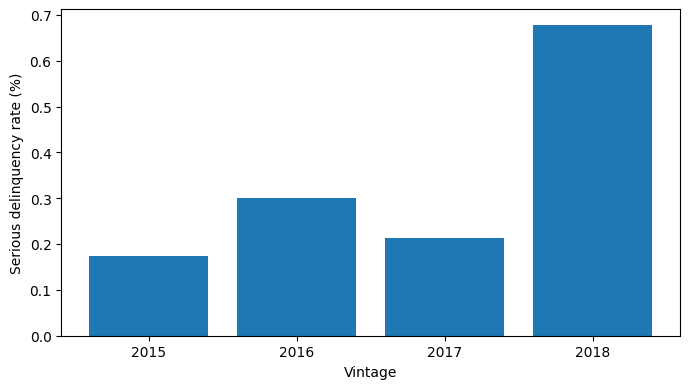

In [ ]:
# Plot and save serious-delinquency event rate by vintage

plt.figure(figsize=(7, 4))

plt.bar(
    summary_by_vintage.index.astype(str),
    summary_by_vintage["event_rate_percent"]
)

plt.xlabel("Vintage")
plt.ylabel("Serious delinquency rate (%)")

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_2_Event_Rate_by_Vintage.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

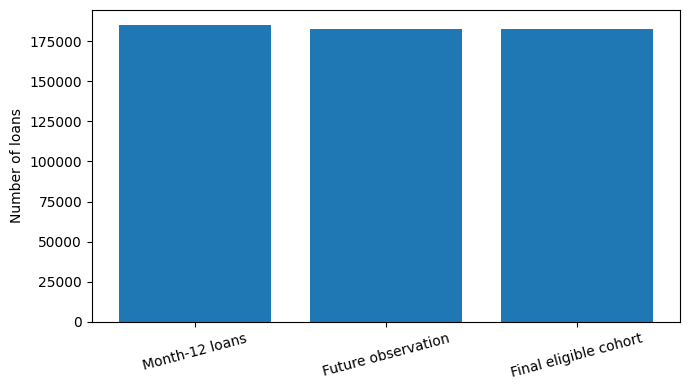

In [ ]:
# Plot and save the main cohort-construction stages

cohort_counts = pd.Series({
    "Month-12 loans": len(month12_status),
    "Future observation": (cohort["future_months_observed"] > 0).sum(),
    "Final eligible cohort": len(final_cohort)
})

plt.figure(figsize=(7, 4))

plt.bar(
    cohort_counts.index,
    cohort_counts.values
)

plt.ylabel("Number of loans")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_3_Cohort_Construction.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Behavioural and Month-12 Feature Engineering

In [ ]:
# Engineer behavioural features using only information available through Month 12

eligible_ids = set(final_cohort["loan_sequence_number"])

obs_final = svcg[
    svcg["loan_sequence_number"].isin(eligible_ids) &
    svcg["original_loan_age"].between(0, 12)
].copy()

obs_final = obs_final.sort_values(
    ["loan_sequence_number", "original_loan_age"]
)

obs_final["is_30plus"] = (
    obs_final["delinquency_numeric"] >= 1
).astype(int)

obs_final["is_60plus"] = (
    obs_final["delinquency_numeric"] >= 2
).astype(int)

obs_final["is_90plus"] = (
    obs_final["serious_delinquency"] == 1
).astype(int)

obs_final["recent_30plus"] = (
    obs_final["original_loan_age"].between(10, 12) &
    (obs_final["delinquency_numeric"] >= 1)
).astype(int)

obs_final["modified_indicator"] = (
    obs_final["modification_flag"]
    .astype(str)
    .isin(["Y", "P"])
).astype(int)

behavioural = (
    obs_final
    .groupby("loan_sequence_number")
    .agg(
        months_observed_0_12=("original_loan_age", "nunique"),
        maximum_delinquency_0_12=("delinquency_numeric", "max"),
        number_30plus_months_0_12=("is_30plus", "sum"),
        number_60plus_months_0_12=("is_60plus", "sum"),
        number_90plus_months_0_12=("is_90plus", "sum"),
        recent_30plus_months_10_12=("recent_30plus", "sum"),
        ever_modified_0_12=("modified_indicator", "max"),
        minimum_upb_0_12=("current_actual_upb", "min"),
        maximum_upb_0_12=("current_actual_upb", "max"),
        mean_upb_0_12=("current_actual_upb", "mean"),
        first_upb_0_12=("current_actual_upb", "first"),
        last_upb_0_12=("current_actual_upb", "last"),
        mean_interest_rate_0_12=("current_interest_rate", "mean"),
        mean_estimated_ltv_0_12=("estimated_ltv", "mean")
    )
    .reset_index()
)

behavioural["upb_change_0_12"] = (
    behavioural["last_upb_0_12"] -
    behavioural["first_upb_0_12"]
)

behavioural["upb_reduction_ratio_0_12"] = (
    (
        behavioural["first_upb_0_12"] -
        behavioural["last_upb_0_12"]
    ) /
    behavioural["first_upb_0_12"]
)

print("Behavioural rows:", f"{len(behavioural):,}")
print("Unique loans:", f"{behavioural['loan_sequence_number'].nunique():,}")

Behavioural rows: 182,987
Unique loans: 182,987


In [ ]:
# Create Month-12 monitoring variables
# month12_upb is retained for financial-cost calculation only.

month12_features = month12[
    [
        "loan_sequence_number",
        "current_actual_upb",
        "delinquency_numeric",
        "current_interest_rate",
        "estimated_ltv"
    ]
].copy()

month12_features = month12_features.rename(
    columns={
        "current_actual_upb": "month12_upb",
        "delinquency_numeric": "month12_delinquency",
        "current_interest_rate": "month12_interest_rate",
        "estimated_ltv": "month12_estimated_ltv"
    }
)

print("Month-12 rows:", f"{len(month12_features):,}")
print("Unique loans:", f"{month12_features['loan_sequence_number'].nunique():,}")
print("Month-12 UPB available:", "month12_upb" in month12_features.columns)

Month-12 rows: 185,323
Unique loans: 185,323
Month-12 UPB available: True


##Modelling Dataset

In [ ]:
# Build modelling dataset
orig_features = [
    "loan_sequence_number",
    "credit_score",
    "mi_percent",
    "first_time_homebuyer_flag",
    "occupancy_status",
    "original_dti",
    "original_upb",
    "original_ltv",
    "loan_purpose",
    "number_of_borrowers",
    "property_type",
    "property_state"
]

behavioural_features = [
    "loan_sequence_number",
    "maximum_delinquency_0_12",
    "number_30plus_months_0_12",
    "recent_30plus_months_10_12",
    "upb_reduction_ratio_0_12"
]

model_data = (
    final_cohort[
        ["loan_sequence_number", "vintage", "target"]
    ]
    .merge(
        orig[orig_features],
        on="loan_sequence_number",
        how="left"
    )
    .merge(
        behavioural[behavioural_features],
        on="loan_sequence_number",
        how="left"
    )
    .merge(
        month12_features,
        on="loan_sequence_number",
        how="left"
    )
)

print("Model dataset:", model_data.shape)
print("Unique loans:", model_data["loan_sequence_number"].nunique())
print("Duplicates:", model_data["loan_sequence_number"].duplicated().sum())

print("\nTarget distribution:")
print(model_data["target"].value_counts())

print("\nMonth-12 UPB present:", "month12_upb" in model_data.columns)
print("Missing Month-12 UPB:", model_data["month12_upb"].isna().sum())


Model dataset: (182987, 22)
Unique loans: 182987
Duplicates: 0

Target distribution:
target
0    182369
1       618
Name: count, dtype: int64

Month-12 UPB present: True
Missing Month-12 UPB: 0


In [ ]:
# Define raw predictor groups
# property_state is kept separate because it will use WOE rather than one-hot encoding.

numeric_features = [
    "credit_score",
    "mi_percent",
    "original_dti",
    "original_upb",
    "original_ltv",
    "number_of_borrowers",
    "maximum_delinquency_0_12",
    "number_30plus_months_0_12",
    "recent_30plus_months_10_12",
    "upb_reduction_ratio_0_12",
    "month12_delinquency",
    "month12_interest_rate",
    "month12_estimated_ltv"
]

categorical_features = [
    "first_time_homebuyer_flag",
    "occupancy_status",
    "loan_purpose",
    "property_type"
]

woe_features = [
    "property_state"
]

selected_features = numeric_features + categorical_features + woe_features

print("Numeric predictors:", len(numeric_features))
print("One-hot categorical predictors:", len(categorical_features))
print("WOE predictors:", len(woe_features))
print("Total raw predictors:", len(selected_features))

print(
    "All selected predictors present:",
    all(col in model_data.columns for col in selected_features)
)

print(
    "month12_upb used as predictor:",
    "month12_upb" in selected_features
)


Numeric predictors: 13
One-hot categorical predictors: 4
WOE predictors: 1
Total raw predictors: 18
All selected predictors present: True
month12_upb used as predictor: False


In [ ]:
# Check missingness in the raw predictor set

missing_pct = (
    model_data[selected_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_table = pd.DataFrame({
    "missing_count": model_data[selected_features].isna().sum(),
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

display(
    missing_table[
        missing_table["missing_count"] > 0
    ]
)


,missing_count,missing_percent
month12_estimated_ltv,65948,36.039719
original_dti,8514,4.652790
credit_score,18,0.009837
original_ltv,2,0.001093


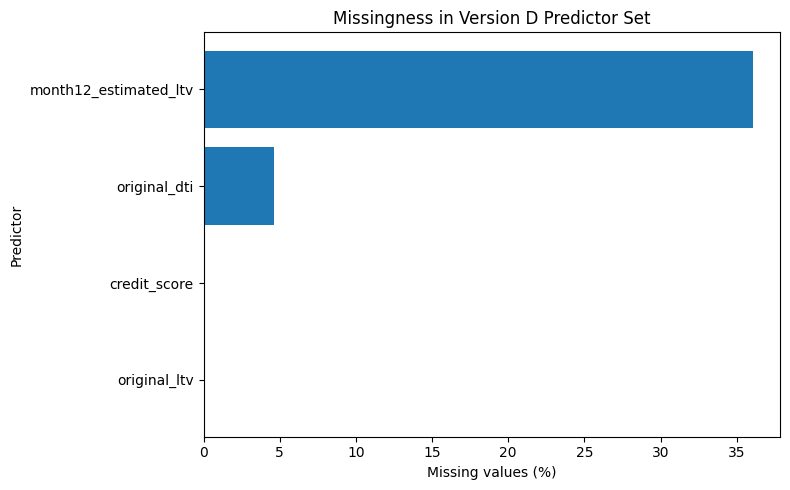

In [ ]:
# Plot and save missingness among the selected predictors

missing_plot = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 5))

plt.barh(
    missing_plot.index[::-1],
    missing_plot.values[::-1]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Predictor")
plt.title("Missingness in Version D Predictor Set")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure_4_Feature_Missingness.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

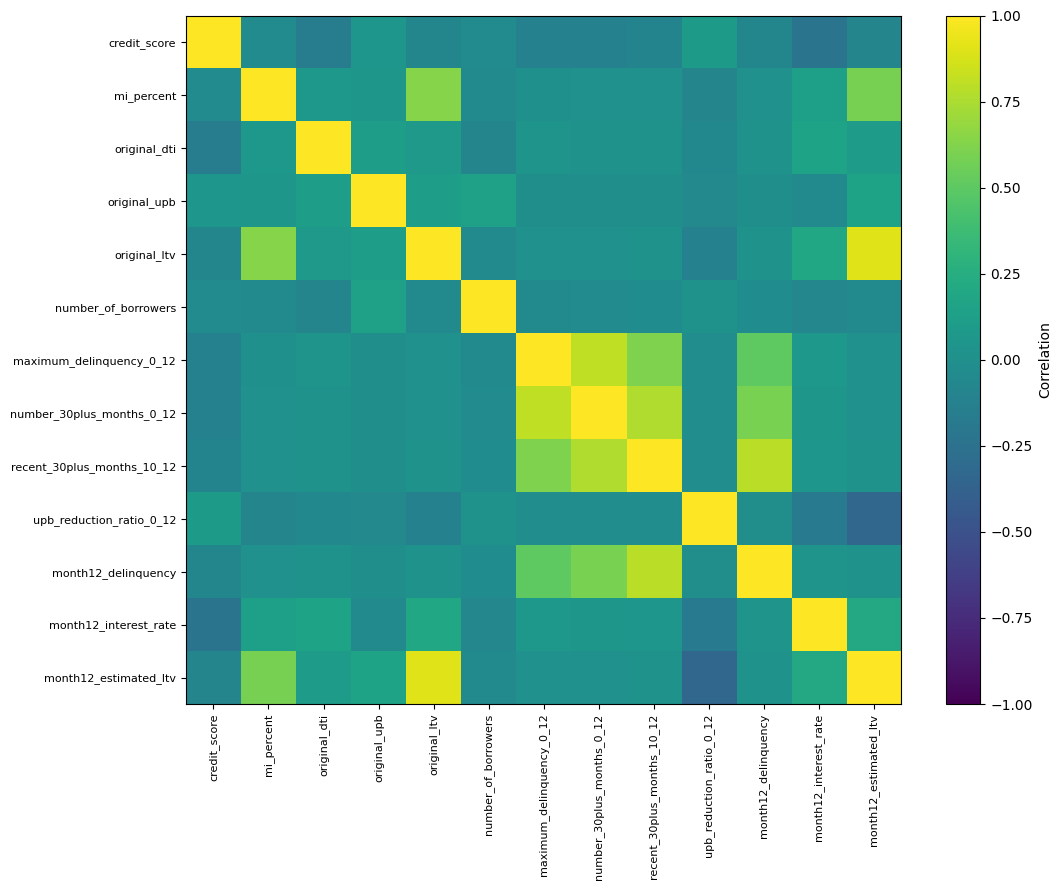

In [ ]:
# Plot and save the correlation matrix for the numeric predictors

corr = model_data[numeric_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(numeric_features)))
ax.set_yticks(range(len(numeric_features)))

ax.set_xticklabels(
    numeric_features,
    rotation=90,
    fontsize=8
)

ax.set_yticklabels(
    numeric_features,
    fontsize=8
)

fig.colorbar(im, ax=ax, label="Correlation")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure_5_Selected_Feature_Correlation.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Chronological Split and Preprocessing

In [ ]:
# Split chronologically into training, validation and untouched test cohorts

train_data = model_data[
    model_data["vintage"].isin([2015, 2016])
].copy()

val_data = model_data[
    model_data["vintage"] == 2017
].copy()

test_data = model_data[
    model_data["vintage"] == 2018
].copy()

X_train = train_data[selected_features].copy()
y_train = train_data["target"].copy()

X_val = val_data[selected_features].copy()
y_val = val_data["target"].copy()

X_test = test_data[selected_features].copy()
y_test = test_data["target"].copy()

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

print("\nTrain target:")
print(y_train.value_counts())

print("\nValidation target:")
print(y_val.value_counts())

print("\nTest target:")
print(y_test.value_counts())


Train: (92295, 22)
Validation: (46626, 22)
Test: (44066, 22)

Train target:
target
0    92075
1      220
Name: count, dtype: int64

Validation target:
target
0    46527
1       99
Name: count, dtype: int64

Test target:
target
0    43767
1      299
Name: count, dtype: int64


In [ ]:
# Rebuild raw predictor matrices so this cell can be rerun safely
X_train = train_data[selected_features].copy()
X_val = val_data[selected_features].copy()
X_test = test_data[selected_features].copy()

# Apply training-only WOE encoding to property_state

def fit_woe_mapping(category_series, target, smoothing=0.5):
    temp = pd.DataFrame({
        "category": category_series.astype("object").fillna("__MISSING__"),
        "target": np.asarray(target)
    })

    grouped = temp.groupby("category", dropna=False)["target"].agg(
        events="sum",
        total="count"
    )

    grouped["non_events"] = grouped["total"] - grouped["events"]

    n_categories = len(grouped)
    total_events = grouped["events"].sum()
    total_non_events = grouped["non_events"].sum()

    grouped["event_share"] = (
        (grouped["events"] + smoothing) /
        (total_events + smoothing * n_categories)
    )

    grouped["non_event_share"] = (
        (grouped["non_events"] + smoothing) /
        (total_non_events + smoothing * n_categories)
    )

    grouped["woe"] = np.log(
        grouped["event_share"] /
        grouped["non_event_share"]
    )

    return grouped["woe"].to_dict()


def apply_woe_mapping(category_series, mapping):
    return (
        category_series
        .astype("object")
        .fillna("__MISSING__")
        .map(mapping)
        .fillna(0.0)
        .astype(float)
    )


# Learn WOE mapping from 2015-2016 training data only
property_state_woe_map = fit_woe_mapping(
    X_train["property_state"],
    y_train
)

# Apply the fixed training mapping to train, validation and test
for X in [X_train, X_val, X_test]:
    X["property_state_woe"] = apply_woe_mapping(
        X["property_state"],
        property_state_woe_map
    )

    X.drop(
        columns=["property_state"],
        inplace=True
    )


# Final feature groups after WOE transformation
model_numeric_features = (
    numeric_features + ["property_state_woe"]
)

model_features = (
    model_numeric_features + categorical_features
)


# Numeric preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Low-cardinality categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, model_numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])


# Fit preprocessing on training only
X_train_processed = preprocessor.fit_transform(
    X_train[model_features]
)

X_val_processed = preprocessor.transform(
    X_val[model_features]
)

X_test_processed = preprocessor.transform(
    X_test[model_features]
)


print(
    "WOE states learned from training:",
    len(property_state_woe_map)
)

print(
    "Train processed:",
    X_train_processed.shape
)

print(
    "Validation processed:",
    X_val_processed.shape
)

print(
    "Test processed:",
    X_test_processed.shape
)

WOE states learned from training: 54
Train processed: (92295, 28)
Validation processed: (46626, 28)
Test processed: (44066, 28)


## Model Training

In [ ]:
# Train the four final model configurations

lr_baseline = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_weighted = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

brf = BalancedRandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models = {
    "Unweighted LR": lr_baseline,
    "Weighted LR": lr_weighted,
    "Balanced RF": brf,
    "Weighted XGBoost": xgb
}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    print("Trained:", name)

Trained: Unweighted LR
Trained: Weighted LR
Trained: Balanced RF
Trained: Weighted XGBoost


## 2017 Validation Evaluation

In [ ]:
# Evaluate all models on the 2017 validation cohort at threshold 0.50

val_probabilities = {}
validation_rows = []

for model_name, model in models.items():
    probabilities = model.predict_proba(X_val_processed)[:, 1]
    pred = (probabilities >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    val_probabilities[model_name] = probabilities

    validation_rows.append([
        model_name,
        roc_auc_score(y_val, probabilities),
        average_precision_score(y_val, probabilities),
        precision_score(y_val, pred, zero_division=0),
        recall_score(y_val, pred),
        f1_score(y_val, pred),
        brier_score_loss(y_val, probabilities),
        log_loss(y_val, probabilities),
        tp, fp, fn, tn
    ])

validation_results = pd.DataFrame(
    validation_rows,
    columns=[
        "Model", "ROC_AUC", "PR_AUC", "Precision", "Recall", "F1",
        "Brier", "Log_Loss", "TP", "FP", "FN", "TN"
    ]
)

display(validation_results.round(4))

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier,Log_Loss,TP,FP,FN,TN
0,Unweighted LR,0.8857,0.2999,0.6571,0.2323,0.3433,0.0017,0.0098,23,12,76,46515
1,Weighted LR,0.8889,0.2759,0.0116,0.7677,0.0229,0.1030,0.3450,76,6465,23,40062
2,Balanced RF,0.8945,0.2027,0.0168,0.7273,0.0328,0.0794,0.2854,72,4214,27,42313
3,Weighted XGBoost,0.8784,0.2060,0.0371,0.6263,0.0701,0.0272,0.1014,62,1607,37,44920


In [ ]:
# Find each model's cost-optimal validation threshold

thresholds = np.linspace(0.001, 0.999, 999)

val_balance = val_data["month12_upb"].to_numpy()
y_val_array = y_val.to_numpy()

def calculate_cost_curve(
    y_true,
    probabilities,
    balances,
    lgd,
    fp_cost
):
    rows = []

    for threshold in thresholds:
        pred = (probabilities >= threshold).astype(int)

        fn_cost = balances[
            (y_true == 1) & (pred == 0)
        ].sum() * lgd

        fp_total = (
            ((y_true == 0) & (pred == 1)).sum()
            * fp_cost
        )

        rows.append([
            threshold,
            fn_cost + fp_total,
            fn_cost,
            fp_total
        ])

    return pd.DataFrame(
        rows,
        columns=[
            "threshold",
            "total_cost",
            "fn_cost",
            "fp_cost"
        ]
    )

cost_results = {}
optimal_rows = []

for model_name, probabilities in val_probabilities.items():

    result = calculate_cost_curve(
        y_val_array,
        probabilities,
        val_balance,
        LGD,
        FP_COST
    )

    optimum = result.loc[
        result["total_cost"].idxmin()
    ]

    cost_results[model_name] = result

    optimal_rows.append([
        model_name,
        optimum["threshold"],
        optimum["total_cost"],
        optimum["fn_cost"],
        optimum["fp_cost"]
    ])

optimal_thresholds = pd.DataFrame(
    optimal_rows,
    columns=[
        "Model",
        "Optimal_Threshold",
        "Total_Cost",
        "FN_Cost",
        "FP_Cost"
    ]
)

display(optimal_thresholds.round(2))

,Model,Optimal_Threshold,Total_Cost,FN_Cost,FP_Cost
0,Unweighted LR,0.01,3725223.95,3294723.95,430500.0
1,Weighted LR,0.91,3580562.50,3135062.50,445500.0
2,Balanced RF,0.79,3356156.12,3076156.12,280000.0
3,Weighted XGBoost,0.24,4591605.42,2582105.42,2009500.0


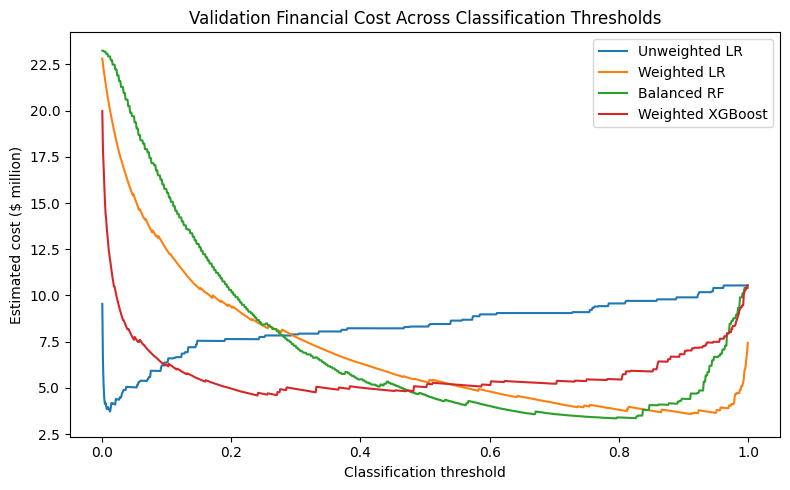

In [ ]:
# Plot and save validation financial cost across classification thresholds

plt.figure(figsize=(8, 5))

for model_name, result in cost_results.items():
    plt.plot(
        result["threshold"],
        result["total_cost"] / 1_000_000,
        label=model_name
    )

plt.xlabel("Classification threshold")
plt.ylabel("Estimated cost ($ million)")
plt.title("Validation Financial Cost Across Classification Thresholds")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_6_Cost_vs_Threshold.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Evaluate validation performance at each model's cost-optimal threshold

optimal_rows = []

for model_name, probabilities in val_probabilities.items():

    threshold = optimal_thresholds.loc[
        optimal_thresholds["Model"] == model_name,
        "Optimal_Threshold"
    ].iloc[0]

    pred = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred
    ).ravel()

    optimal_rows.append([
        model_name,
        threshold,
        tp,
        fp,
        fn,
        tn,
        precision_score(y_val, pred, zero_division=0),
        recall_score(y_val, pred),
        f1_score(y_val, pred)
    ])

optimal_performance = pd.DataFrame(
    optimal_rows,
    columns=[
        "Model",
        "Threshold",
        "TP",
        "FP",
        "FN",
        "TN",
        "Precision",
        "Recall",
        "F1"
    ]
)

display(optimal_performance.round(4))

,Model,Threshold,TP,FP,FN,TN,Precision,Recall,F1
0,Unweighted LR,0.013,65,861,34,45666,0.0702,0.6566,0.1268
1,Weighted LR,0.911,66,891,33,45636,0.0690,0.6667,0.1250
2,Balanced RF,0.794,68,560,31,45967,0.1083,0.6869,0.1871
3,Weighted XGBoost,0.241,73,4019,26,42508,0.0178,0.7374,0.0348


In [ ]:
# Run sensitivity analysis across LGD and false-positive review costs

sensitivity_rows = []

for lgd in [0.30, 0.50, 0.70]:
    for fp_cost in [250, 500, 1000]:
        for model_name, probabilities in val_probabilities.items():

            result = calculate_cost_curve(
                y_val_array,
                probabilities,
                val_balance,
                lgd,
                fp_cost
            )

            optimum = result.loc[
                result["total_cost"].idxmin()
            ]

            sensitivity_rows.append([
                lgd,
                fp_cost,
                model_name,
                optimum["threshold"],
                optimum["total_cost"]
            ])

sensitivity_results = pd.DataFrame(
    sensitivity_rows,
    columns=[
        "LGD",
        "FP_Cost",
        "Model",
        "Optimal_Threshold",
        "Minimum_Cost"
    ]
)

display(sensitivity_results.round(2))

,LGD,FP_Cost,Model,Optimal_Threshold,Minimum_Cost
0,0.3,250,Unweighted LR,0.01,2192084.37
1,0.3,250,Weighted LR,0.91,2103787.50
2,0.3,250,Balanced RF,0.79,1985693.68
3,0.3,250,Weighted XGBoost,0.24,2554013.25
4,0.3,500,Unweighted LR,0.01,2407334.37
5,0.3,500,Weighted LR,0.95,2287054.15
6,0.3,500,Balanced RF,0.82,2111855.34
7,0.3,500,Weighted XGBoost,0.48,3238112.13
8,0.3,1000,Unweighted LR,0.02,2770790.25
9,0.3,1000,Weighted LR,0.95,2530554.15


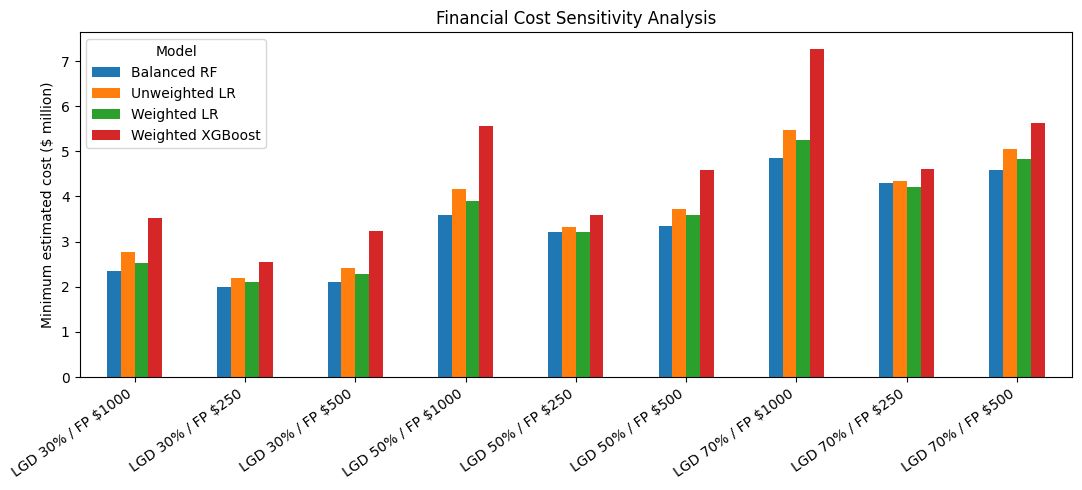

In [ ]:
# Plot and save minimum financial cost across the nine sensitivity scenarios

sensitivity_plot = sensitivity_results.copy()

sensitivity_plot["Scenario"] = (
    "LGD "
    + (sensitivity_plot["LGD"] * 100).astype(int).astype(str)
    + "% / FP $"
    + sensitivity_plot["FP_Cost"].astype(int).astype(str)
)

pivot_cost = sensitivity_plot.pivot(
    index="Scenario",
    columns="Model",
    values="Minimum_Cost"
) / 1_000_000

pivot_cost.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylabel("Minimum estimated cost ($ million)")
plt.xlabel("")
plt.title("Financial Cost Sensitivity Analysis")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Model")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure_7_Cost_Sensitivity.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Locked 2018 Out-of-Time Test

In [ ]:
# Apply the locked validation thresholds to the untouched 2018 test cohort

test_probabilities = {
    name: model.predict_proba(X_test_processed)[:, 1]
    for name, model in models.items()
}

test_balance = test_data["month12_upb"].to_numpy()
y_test_array = y_test.to_numpy()

test_rows = []

for model_name, probabilities in test_probabilities.items():

    threshold = optimal_thresholds.loc[
        optimal_thresholds["Model"] == model_name,
        "Optimal_Threshold"
    ].iloc[0]

    pred = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_array,
        pred
    ).ravel()

    fn_cost = test_balance[
        (y_test_array == 1) & (pred == 0)
    ].sum() * LGD

    fp_cost = fp * FP_COST

    test_rows.append([
        model_name,
        threshold,
        roc_auc_score(y_test_array, probabilities),
        average_precision_score(y_test_array, probabilities),
        precision_score(y_test_array, pred, zero_division=0),
        recall_score(y_test_array, pred),
        f1_score(y_test_array, pred),
        tp, fp, fn, tn,
        fn_cost + fp_cost
    ])

test_results = pd.DataFrame(
    test_rows,
    columns=[
        "Model", "Threshold", "ROC_AUC", "PR_AUC",
        "Precision", "Recall", "F1",
        "TP", "FP", "FN", "TN", "Total_Cost"
    ]
)

display(test_results.round(4))

,Model,Threshold,ROC_AUC,PR_AUC,Precision,Recall,F1,TP,FP,FN,TN,Total_Cost
0,Unweighted LR,0.013,0.7583,0.1540,0.1064,0.3378,0.1619,101,848,198,42919,2.343983e+07
1,Weighted LR,0.911,0.7700,0.1572,0.0903,0.3445,0.1431,103,1038,196,42729,2.298754e+07
2,Balanced RF,0.794,0.7967,0.1146,0.1533,0.3378,0.2109,101,558,198,43209,2.309586e+07
3,Weighted XGBoost,0.241,0.7454,0.1026,0.0263,0.3880,0.0492,116,4300,183,39467,2.370363e+07


In [ ]:
# Calculate paired stratified 95% bootstrap confidence intervals on the 2018 test cohort

rng = np.random.RandomState(RANDOM_STATE)

pos_idx = np.where(y_test_array == 1)[0]
neg_idx = np.where(y_test_array == 0)[0]

bootstrap_store = {
    model: {"roc": [], "pr": []}
    for model in test_probabilities
}

for _ in range(500):

    boot_pos = rng.choice(
        pos_idx,
        size=len(pos_idx),
        replace=True
    )

    boot_neg = rng.choice(
        neg_idx,
        size=len(neg_idx),
        replace=True
    )

    boot_idx = np.concatenate([
        boot_pos,
        boot_neg
    ])

    y_boot = y_test_array[boot_idx]

    for model_name, probabilities in test_probabilities.items():

        p_boot = probabilities[boot_idx]

        bootstrap_store[model_name]["roc"].append(
            roc_auc_score(y_boot, p_boot)
        )

        bootstrap_store[model_name]["pr"].append(
            average_precision_score(y_boot, p_boot)
        )

bootstrap_rows = []

for model_name, probabilities in test_probabilities.items():

    bootstrap_rows.append([
        model_name,
        roc_auc_score(y_test_array, probabilities),
        np.percentile(
            bootstrap_store[model_name]["roc"], 2.5
        ),
        np.percentile(
            bootstrap_store[model_name]["roc"], 97.5
        ),
        average_precision_score(
            y_test_array,
            probabilities
        ),
        np.percentile(
            bootstrap_store[model_name]["pr"], 2.5
        ),
        np.percentile(
            bootstrap_store[model_name]["pr"], 97.5
        )
    ])

bootstrap_ci = pd.DataFrame(
    bootstrap_rows,
    columns=[
        "Model",
        "ROC_AUC",
        "ROC_CI_Lower",
        "ROC_CI_Upper",
        "PR_AUC",
        "PR_CI_Lower",
        "PR_CI_Upper"
    ]
)

display(bootstrap_ci.round(4))

,Model,ROC_AUC,ROC_CI_Lower,ROC_CI_Upper,PR_AUC,PR_CI_Lower,PR_CI_Upper
0,Unweighted LR,0.7583,0.7242,0.7899,0.1540,0.1186,0.2033
1,Weighted LR,0.7700,0.7374,0.7999,0.1572,0.1217,0.2061
2,Balanced RF,0.7967,0.7675,0.8258,0.1146,0.0885,0.1532
3,Weighted XGBoost,0.7454,0.7146,0.7759,0.1026,0.0718,0.1426


In [ ]:
# Prepare a numeric sample of the 2018 test cohort for SHAP analysis

feature_names = preprocessor.get_feature_names_out()

rng = np.random.RandomState(RANDOM_STATE)

sample_idx = rng.choice(
    X_test_processed.shape[0],
    size=2000,
    replace=False
)

X_shap = X_test_processed[sample_idx]

if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()

X_shap = np.asarray(
    X_shap,
    dtype=np.float64
)

print("Shape:", X_shap.shape)
print("Missing:", np.isnan(X_shap).sum())

Shape: (2000, 28)
Missing: 0


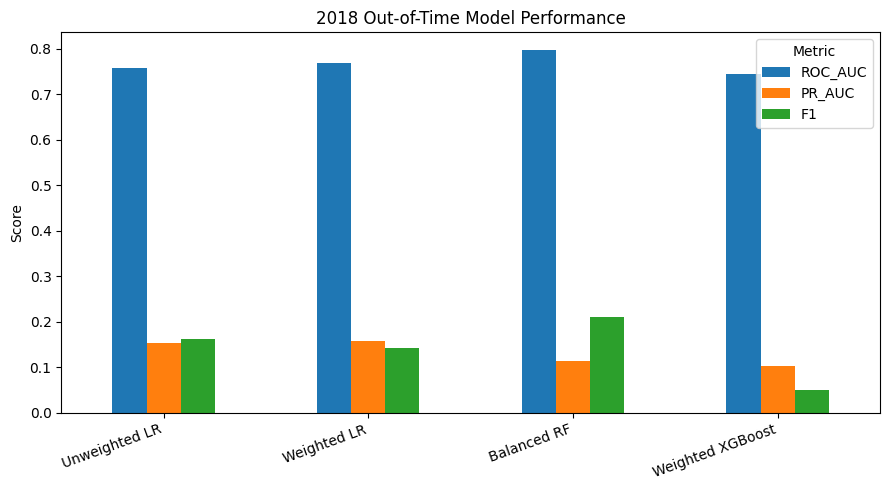

In [ ]:
# Plot and save 2018 out-of-time statistical model performance

performance_plot = (
    test_results[
        ["Model", "ROC_AUC", "PR_AUC", "F1"]
    ]
    .set_index("Model")
)

performance_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.xlabel("")
plt.title("2018 Out-of-Time Model Performance")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_8_OOT_Model_Performance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

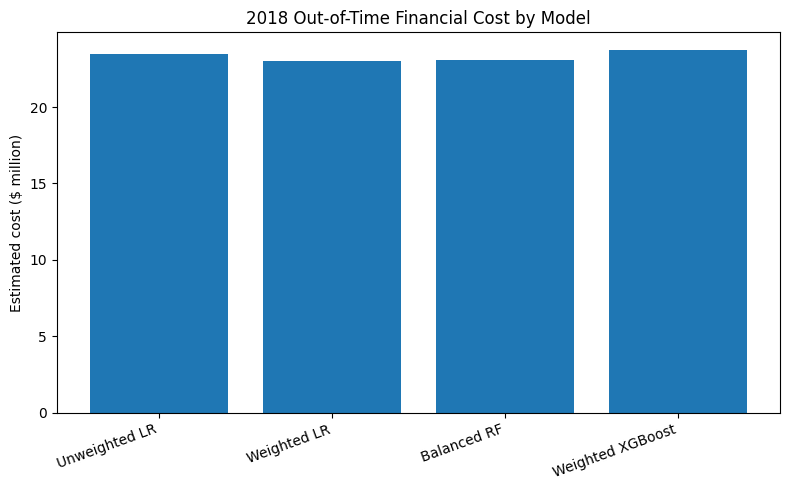

In [ ]:
# Plot and save 2018 out-of-time financial cost by model

cost_plot = test_results.copy()

cost_plot["Total_Cost_Million"] = (
    cost_plot["Total_Cost"] / 1_000_000
)

plt.figure(figsize=(8, 5))

plt.bar(
    cost_plot["Model"],
    cost_plot["Total_Cost_Million"]
)

plt.ylabel("Estimated cost ($ million)")
plt.title("2018 Out-of-Time Financial Cost by Model")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_9_OOT_Financial_Cost.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Interpretation

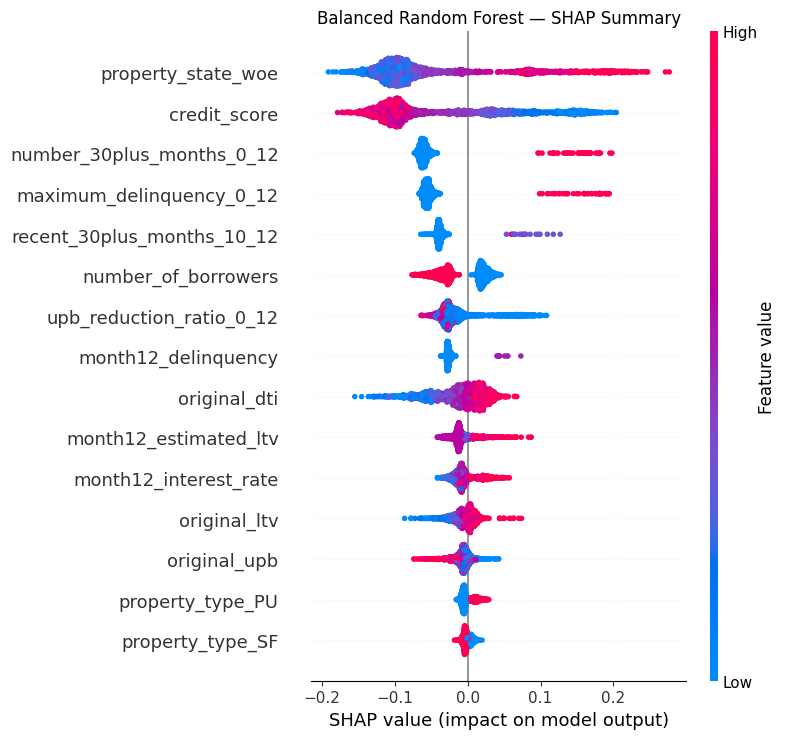

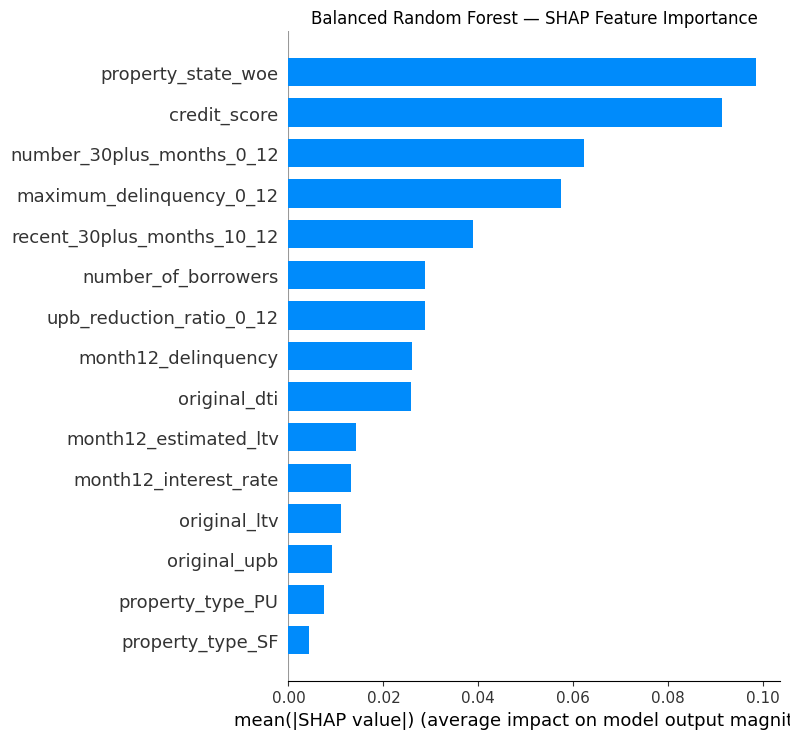

In [ ]:
# SHAP interpretation for the validation-selected Balanced Random Forest

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Clean names for easier interpretation
clean_feature_names = [
    name.replace("numeric__", "")
        .replace("categorical__", "")
    for name in feature_names
]

# Use a manageable random sample from the training data
rng = np.random.RandomState(RANDOM_STATE)

sample_size = min(2000, X_train_processed.shape[0])

sample_idx = rng.choice(
    X_train_processed.shape[0],
    size=sample_size,
    replace=False
)

X_shap = X_train_processed[sample_idx]

# Convert sparse matrix to dense if necessary
if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()

# Create SHAP explainer for Balanced Random Forest
explainer = shap.TreeExplainer(brf)

shap_values = explainer.shap_values(X_shap)

# Select the positive class: deterioration = 1
if isinstance(shap_values, list):
    shap_positive = shap_values[1]

elif shap_values.ndim == 3:
    shap_positive = shap_values[:, :, 1]

else:
    shap_positive = shap_values


# Plot 1: SHAP summary / beeswarm
shap.summary_plot(
    shap_positive,
    X_shap,
    feature_names=clean_feature_names,
    max_display=15,
    show=False
)

plt.title(
    "Balanced Random Forest — SHAP Summary"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure_10_BRF_SHAP_Summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Plot 2: SHAP global feature importance
shap.summary_plot(
    shap_positive,
    X_shap,
    feature_names=clean_feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Balanced Random Forest — SHAP Feature Importance"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure_11_BRF_SHAP_Importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Report-Ready Results

In [ ]:
# Create the final report-ready out-of-time results table

final_results = test_results.merge(
    bootstrap_ci[
        [
            "Model",
            "ROC_CI_Lower",
            "ROC_CI_Upper",
            "PR_CI_Lower",
            "PR_CI_Upper"
        ]
    ],
    on="Model",
    how="left"
)

final_results["ROC-AUC (95% CI)"] = final_results.apply(
    lambda x:
    f"{x['ROC_AUC']:.4f} "
    f"({x['ROC_CI_Lower']:.4f}–{x['ROC_CI_Upper']:.4f})",
    axis=1
)

final_results["PR-AUC (95% CI)"] = final_results.apply(
    lambda x:
    f"{x['PR_AUC']:.4f} "
    f"({x['PR_CI_Lower']:.4f}–{x['PR_CI_Upper']:.4f})",
    axis=1
)

final_results["Total Cost ($M)"] = (
    final_results["Total_Cost"] /
    1_000_000
).round(2)

report_results = final_results[
    [
        "Model",
        "Threshold",
        "ROC-AUC (95% CI)",
        "PR-AUC (95% CI)",
        "Precision",
        "Recall",
        "F1",
        "TP",
        "FP",
        "FN",
        "Total Cost ($M)"
    ]
].copy()

display(report_results.round(4))

,Model,Threshold,ROC-AUC (95% CI),PR-AUC (95% CI),Precision,Recall,F1,TP,FP,FN,Total Cost ($M)
0,Unweighted LR,0.013,0.7583 (0.7242–0.7899),0.1540 (0.1186–0.2033),0.1064,0.3378,0.1619,101,848,198,23.44
1,Weighted LR,0.911,0.7700 (0.7374–0.7999),0.1572 (0.1217–0.2061),0.0903,0.3445,0.1431,103,1038,196,22.99
2,Balanced RF,0.794,0.7967 (0.7675–0.8258),0.1146 (0.0885–0.1532),0.1533,0.3378,0.2109,101,558,198,23.10
3,Weighted XGBoost,0.241,0.7454 (0.7146–0.7759),0.1026 (0.0718–0.1426),0.0263,0.3880,0.0492,116,4300,183,23.70


In [ ]:
# Identify the lowest-cost model on validation and report its locked 2018 result

selected_validation_row = optimal_thresholds.loc[
    optimal_thresholds["Total_Cost"].idxmin()
]

selected_model_name = selected_validation_row["Model"]
selected_threshold = selected_validation_row["Optimal_Threshold"]

selected_test_row = test_results.loc[
    test_results["Model"] == selected_model_name
].iloc[0]

print("Validation-selected model:", selected_model_name)
print("Locked threshold:", round(float(selected_threshold), 4))
print(
    "Validation minimum cost: $",
    f"{selected_validation_row['Total_Cost']:,.2f}"
)
print(
    "2018 test cost: $",
    f"{selected_test_row['Total_Cost']:,.2f}"
)
print(
    "2018 ROC-AUC:",
    round(float(selected_test_row["ROC_AUC"]), 4)
)
print(
    "2018 PR-AUC:",
    round(float(selected_test_row["PR_AUC"]), 4)
)
print(
    "2018 Recall:",
    round(float(selected_test_row["Recall"]), 4)
)

Validation-selected model: Balanced RF
Locked threshold: 0.794
Validation minimum cost: $ 3,356,156.12
2018 test cost: $ 23,095,862.28
2018 ROC-AUC: 0.7967
2018 PR-AUC: 0.1146
2018 Recall: 0.3378


In [ ]:
locked_points = {
    "Unweighted LR":   {"threshold": 0.013, "cost": 3.725, "color": "tab:blue",   "offset": (10, -14)},
    "Weighted LR":     {"threshold": 0.911, "cost": 3.581, "color": "tab:orange", "offset": (-70, 10)},
    "Balanced RF":     {"threshold": 0.794, "cost": 3.356, "color": "tab:green",  "offset": (10, -16)},
    "Weighted XGBoost":{"threshold": 0.241, "cost": 4.592, "color": "tab:red",    "offset": (10, 10)},
}

for name, p in locked_points.items():
    ax.scatter([p["threshold"]], [p["cost"]], color="black",
               s=45, zorder=5, edgecolor="white", linewidth=1)
    ax.annotate(
        f"{p['threshold']:.3f}",
        (p["threshold"], p["cost"]),
        textcoords="offset points", xytext=p["offset"],
        fontsize=8.5, fontweight="bold", color=p["color"]
    )

In [ ]:
display(sensitivity_results.round(2))

,LGD,FP_Cost,Model,Optimal_Threshold,Minimum_Cost
0,0.3,250,Unweighted LR,0.01,2192084.37
1,0.3,250,Weighted LR,0.91,2103787.50
2,0.3,250,Balanced RF,0.79,1985693.68
3,0.3,250,Weighted XGBoost,0.24,2554013.25
4,0.3,500,Unweighted LR,0.01,2407334.37
5,0.3,500,Weighted LR,0.95,2287054.15
6,0.3,500,Balanced RF,0.82,2111855.34
7,0.3,500,Weighted XGBoost,0.48,3238112.13
8,0.3,1000,Unweighted LR,0.02,2770790.25
9,0.3,1000,Weighted LR,0.95,2530554.15
